# 1. Exploratory Data Analysis (EDA) and Preprocessing
This notebook covers the EDA and preprocessing pipeline for the AuraCart E-Commerce Analytics and MLOps System project.

## 1. Import Required Libraries
We import all necessary libraries for data analysis, visualization, and preprocessing.

In [1]:
# Install required package for dataset loading
%pip install datasets -q

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from datasets import load_dataset
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

Note: you may need to restart the kernel to use updated packages.


c:\Users\UsEr\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Project Requirements and Dataset Overview
- Perform EDA on the e-commerce dataset from Hugging Face.
- Build a robust, reusable preprocessing pipeline for downstream modeling.
- Save the pipeline for use in deployment.

**Dataset:** [millat/e-commerce-orders](https://huggingface.co/datasets/millat/e-commerce-orders)

**Key Features:**
- Numerical: price, quantity
- Categorical: category, payment_method, device_type, channel, customer_segment, delivery_status
- Date/time: order_date, shipping_date
- ID columns: order_id, customer_id, product_id (to be dropped)
- Address columns: shipping_address, billing_address (to be dropped or engineered)

We will:
- Analyze distributions, correlations, and class balance
- Engineer features from dates
- Encode categorical variables
- Scale numerical features
- Save the final pipeline

## 3. Download and Load the Dataset
We will load the dataset directly from Hugging Face using pandas.

In [2]:
!pip install datasets
from datasets import load_dataset

# Load the dataset from Hugging Face
dataset = load_dataset("millat/e-commerce-orders")

# Convert the 'train' split to a pandas DataFrame
df = dataset['train'].to_pandas()

# Show the first few rows
df.head()

,order_id,customer_id,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment
0,b8ec9f86-5919-4b71-a5f7-945e7c0a3db0,2031,845,Books,45.95,4,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,PayPal,Mobile,Paid Search,"976 Kevin Station, Davidmouth, Hawaii 92563","38182 Ariel Expressway, Campbellland, Oklahoma...",VIP
1,5ea92c47-c5b2-4bdd-8a50-d77efd77ec89,2350,995,Electronics,403.17,3,2024-04-20 14:59:58.897063,2024-04-22 14:59:58.897063,Delivered,PayPal,Mobile,Paid Search,"72166 Cunningham Crescent, East Nicholasside, ...","38199 Edwin Plain, Johnborough, Maine 81826",Returning
2,5cc48ce0-2c6d-4448-af3f-96f8a910d45b,1818,997,Beauty,317.45,2,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,Credit Card,Mobile,Email,"2446 Johnson Junctions, Lynchtown, Minnesota 7...","58086 Smith Stream Suite 994, Lake Pamelabury,...",Returning
3,74d5c0f4-53f0-4367-a5c5-baaa114c2d9f,472,385,Home,24.08,3,2024-04-20 14:59:58.897063,2024-04-24 14:59:58.897063,Shipped,PayPal,Tablet,Social,"3113 Jessica Knolls, North Joshuafort, Alabama...","484 Palmer Harbors Apt. 866, Dustintown, Nebra...",VIP
4,7a630323-8ac8-406e-875a-4bcdead440ab,1075,31,Clothing,494.90,1,2024-04-20 14:59:58.897063,2024-04-25 14:59:58.897063,Delivered,PayPal,Tablet,Organic,"58196 Burgess Heights Suite 315, Douglasland, ...","67094 Schaefer Villages Suite 369, Douglasches...",VIP


## 4. Initial Data Exploration
We will inspect the data types, missing values, and basic statistics.

In [4]:
# Data info and missing values
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          10000 non-null  object 
 1   customer_id       10000 non-null  int64  
 2   product_id        10000 non-null  int64  
 3   category          10000 non-null  object 
 4   price             10000 non-null  float64
 5   quantity          10000 non-null  int64  
 6   order_date        10000 non-null  object 
 7   shipping_date     10000 non-null  object 
 8   delivery_status   10000 non-null  object 
 9   payment_method    10000 non-null  object 
 10  device_type       10000 non-null  object 
 11  channel           10000 non-null  object 
 12  shipping_address  10000 non-null  object 
 13  billing_address   10000 non-null  object 
 14  customer_segment  10000 non-null  object 
dtypes: float64(1), int64(3), object(11)
memory usage: 1.1+ MB


order_id            0
customer_id         0
product_id          0
category            0
price               0
quantity            0
order_date          0
shipping_date       0
delivery_status     0
payment_method      0
device_type         0
channel             0
shipping_address    0
billing_address     0
customer_segment    0
dtype: int64

In [5]:
# Basic statistics for numerical columns
df.describe()

,customer_id,product_id,price,quantity
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,995.292300,504.872400,252.550681,2.124700
std,893.279854,288.281942,141.394146,1.254315
min,1.000000,1.000000,5.060000,1.000000
25%,182.000000,260.000000,130.607500,1.000000
50%,754.000000,507.000000,252.910000,2.000000
75%,1668.500000,752.000000,374.917500,3.000000
max,2999.000000,1000.000000,499.930000,9.000000


In [7]:
# Value counts for key categorical columns
categorical_cols = ['category', 'payment_method', 'device_type', 'channel', 'customer_segment', 'delivery_status']
for col in categorical_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


category value counts:
category
Home           1713
Electronics    1694
Beauty         1682
Toys           1666
Books          1625
Clothing       1620
Name: count, dtype: int64

payment_method value counts:
payment_method
Apple Pay      2068
Debit Card     2002
Google Pay     1986
PayPal         1977
Credit Card    1967
Name: count, dtype: int64

device_type value counts:
device_type
Desktop    3383
Tablet     3339
Mobile     3278
Name: count, dtype: int64

channel value counts:
channel
Social         2566
Paid Search    2525
Email          2474
Organic        2435
Name: count, dtype: int64

customer_segment value counts:
customer_segment
VIP          5149
Returning    4285
New           566
Name: count, dtype: int64

delivery_status value counts:
delivery_status
Delivered    7047
Shipped      1938
Pending       513
Returned      502
Name: count, dtype: int64


## 5. Visualize Distributions and Correlations
We will plot histograms, boxplots, and a correlation heatmap for numerical features.

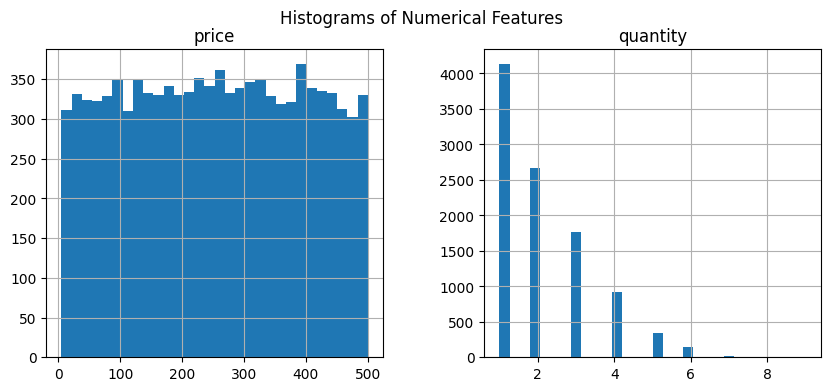

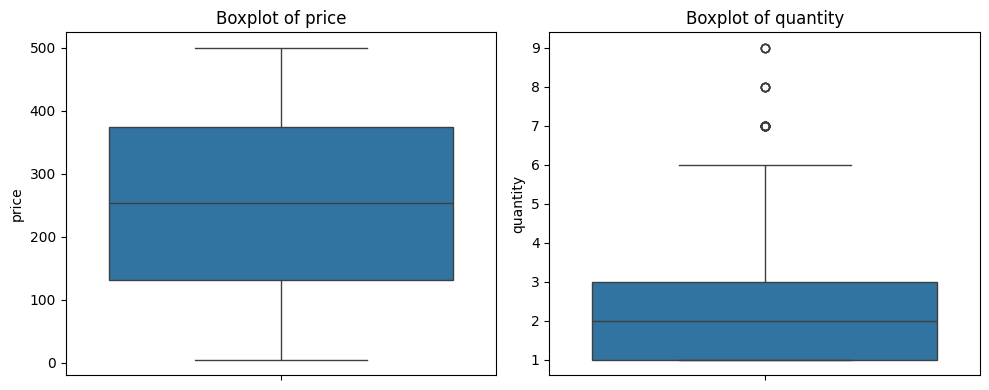

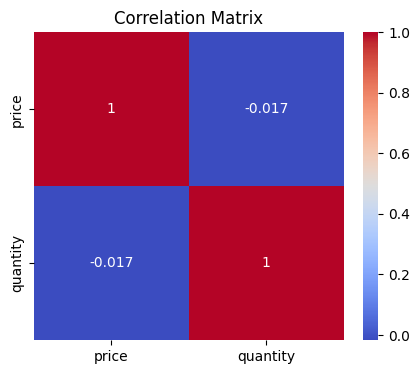

In [8]:
# Histograms for numerical features
num_cols = ['price', 'quantity']
df[num_cols].hist(bins=30, figsize=(10, 4))
plt.suptitle('Histograms of Numerical Features')
plt.show()

# Boxplots for outlier detection
plt.figure(figsize=(10, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Correlation heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 6. Feature Engineering and Data Cleaning
We will drop unnecessary columns, extract features from dates, and handle missing values.

In [10]:
# Drop ID and address columns
drop_cols = ['order_id', 'customer_id', 'product_id', 'shipping_address', 'billing_address']
df_clean = df.drop(columns=drop_cols)

# Convert date columns to datetime
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])
df_clean['shipping_date'] = pd.to_datetime(df_clean['shipping_date'])

# Feature engineering: extract year, month, day, hour from order_date
for col in ['order_date', 'shipping_date']:
    df_clean[f'{col}_year'] = df_clean[col].dt.year
    df_clean[f'{col}_month'] = df_clean[col].dt.month
    df_clean[f'{col}_day'] = df_clean[col].dt.day
    df_clean[f'{col}_hour'] = df_clean[col].dt.hour

# Feature: days between order and shipping
df_clean['days_to_ship'] = (df_clean['shipping_date'] - df_clean['order_date']).dt.days

# Drop original date columns
df_clean = df_clean.drop(columns=['order_date', 'shipping_date'])

# Handle missing values (simple fill for demonstration)
df_clean = df_clean.fillna({'days_to_ship': df_clean['days_to_ship'].median()})
df_clean = df_clean.dropna()
df_clean.head()

,category,price,quantity,delivery_status,payment_method,device_type,channel,customer_segment,order_date_year,order_date_month,order_date_day,order_date_hour,shipping_date_year,shipping_date_month,shipping_date_day,shipping_date_hour,days_to_ship
0,Books,45.95,4,Shipped,PayPal,Mobile,Paid Search,VIP,2024,4,20,14,2024,4,27,14,7
1,Electronics,403.17,3,Delivered,PayPal,Mobile,Paid Search,Returning,2024,4,20,14,2024,4,22,14,2
2,Beauty,317.45,2,Shipped,Credit Card,Mobile,Email,Returning,2024,4,20,14,2024,4,27,14,7
3,Home,24.08,3,Shipped,PayPal,Tablet,Social,VIP,2024,4,20,14,2024,4,24,14,4
4,Clothing,494.90,1,Delivered,PayPal,Tablet,Organic,VIP,2024,4,20,14,2024,4,25,14,5


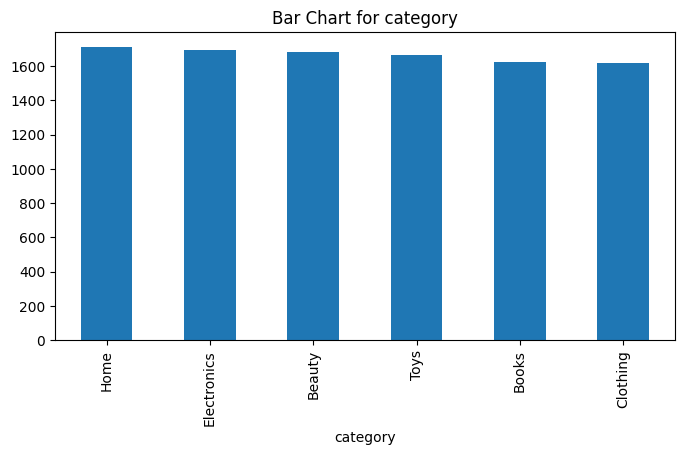

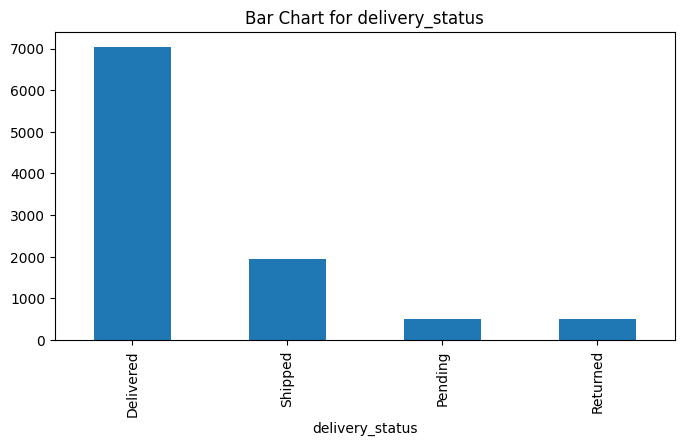

In [11]:
for col in ['category', 'delivery_status']:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Bar Chart for {col}')
    plt.show()

## 7. Preprocessing Pipeline Construction
We will build a Scikit-learn pipeline to encode categorical variables and scale numerical features.

In [12]:
# Identify columns for preprocessing
categorical_nominal = ['category', 'payment_method', 'device_type', 'channel']
categorical_ordinal = []  # No clear ordinal columns in this dataset
categorical_targets = ['customer_segment', 'delivery_status']
numerical = ['price', 'quantity', 'order_date_year', 'order_date_month', 'order_date_day', 'order_date_hour',
             'shipping_date_year', 'shipping_date_month', 'shipping_date_day', 'shipping_date_hour', 'days_to_ship']

# One-hot encode nominal categorical features
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical),
    ('cat_nom', OneHotEncoder(handle_unknown='ignore'), categorical_nominal)
], remainder='passthrough')

# Example: fit the pipeline on the cleaned data (excluding targets)
X = df_clean.drop(columns=categorical_targets)
preprocessor.fit(X)

# Transform the data
X_processed = preprocessor.transform(X)
X_processed.shape

(10000, 29)

## 8. Save the Preprocessing Pipeline
We will serialize the fitted pipeline for use in model training and deployment.

In [14]:
# Save the fitted preprocessing pipeline
os.makedirs('../artifacts', exist_ok=True)
joblib.dump(preprocessor, '../artifacts/preprocessing_pipeline.joblib')
print('Preprocessing pipeline saved to ../artifacts/preprocessing_pipeline.joblib')

Preprocessing pipeline saved to ../artifacts/preprocessing_pipeline.joblib


## 9. Summary of Key EDA Findings
- The dataset contains both numerical and categorical features, with some class imbalance in target variables.
- Feature engineering from dates and removal of ID/address columns improves data quality.
- The preprocessing pipeline is now ready for use in model training and deployment.